# #1 : Setup

In [1]:
import sys
print("Python executable:", sys.executable)

import mlflow
print("✅ MLflow imported successfully!")
print("MLflow version:", mlflow.__version__)

Python executable: /Users/amritanshudash/Desktop/ChurnGuard/venv/bin/python


/Users/amritanshudash/Desktop/ChurnGuard/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ MLflow imported successfully!
MLflow version: 3.13.0


In [2]:
import mlflow
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# MLflow setup
project_root = os.path.dirname(os.getcwd())
mlflow.set_tracking_uri(f"file:{os.path.join(project_root, 'mlruns')}")
mlflow.set_experiment("ChurnGuard_Baseline")

print("Setup ready!")
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# MLflow setup
project_root = os.path.dirname(os.getcwd())
mlflow.set_tracking_uri(f"file:{os.path.join(project_root, 'mlruns')}")
mlflow.set_experiment("ChurnGuard_Baseline")

print("Setup ready!")

Setup ready!
Setup ready!


# #2 : Load Preprocessed Data (Run after EDA notebook)

In [3]:
df = pd.read_csv("../notebooks/churn_data.csv")

df = df.drop(columns=['RowNumber', 'Surname'])
df = pd.get_dummies(df, columns=['Gender', 'Geography'], drop_first=True)

X = df.drop(columns=['Exited'])
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

print("Data preprocessing completed!")

Data preprocessing completed!


# #3 : Train Multiple Models + Compare in MLflow

In [4]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, learning_rate=0.1)
}

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        mlflow.log_param("model_type", name)
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision", prec)
        mlflow.log_metric("recall", rec)
        mlflow.log_metric("f1_score", f1)

        print(f"{name} - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1 Score: {f1:.4f}")

RandomForest - Accuracy: 0.8635, Precision: 0.7479, Recall: 0.4606, F1 Score: 0.5701
XGBoost - Accuracy: 0.8640, Precision: 0.7300, Recall: 0.4885, F1 Score: 0.5854


# #4 : SHAP Explainability

"""
SHAP EXPLAINABILITY - SIMPLE NOTES

What is SHAP?
- SHAP = SHapley Additive exPlanations
- It is a technique that explains WHY a model made a particular prediction.

How does SHAP work?
- It breaks down the model's prediction into contributions from each feature.
- It tells us how much each feature (Age, Balance, etc.) pushed the prediction 
  towards "Churn" or "No Churn".

Why do we use SHAP?
1. To build trust - Stakeholders want to know "Why did the model say this?"
2. To debug the model - Find if it's using wrong or unfair features.
3. For business decisions - Helps customer service understand why a customer might leave.
4. Required in many industries (Banking, Insurance, Healthcare).

Two Main SHAP Plots:

1. Summary Plot (Global View)
   - Shows which features are most important overall in the dataset.
   - Example: "Age and Balance are the top reasons for churn."

2. Force Plot (Local View)
   - Explains one single customer's prediction.
   - Shows which features pushed towards churn and which pushed against it.

In short:
- Random Forest / XGBoost tells us "This customer will churn"
- SHAP tells us "This customer will churn because of high age + low balance"
"""

SHAP values calculated!


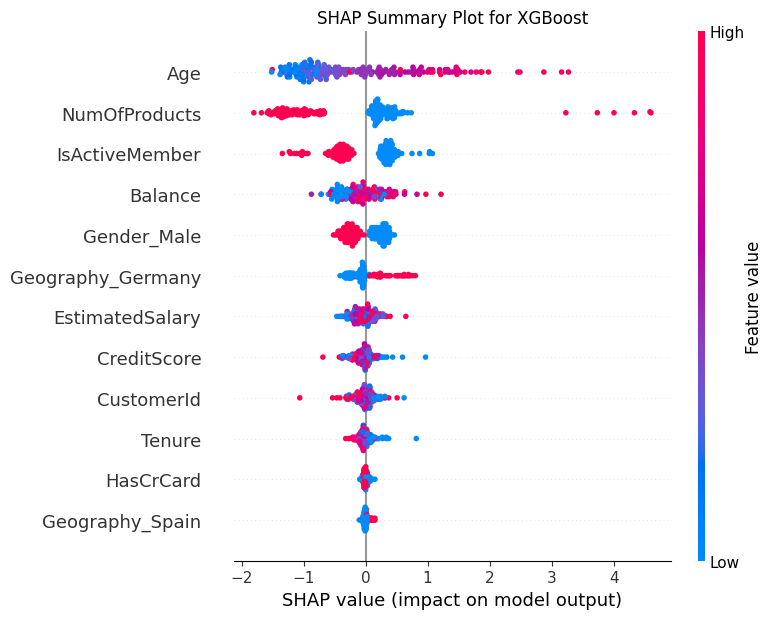

<Figure size 1200x400 with 0 Axes>

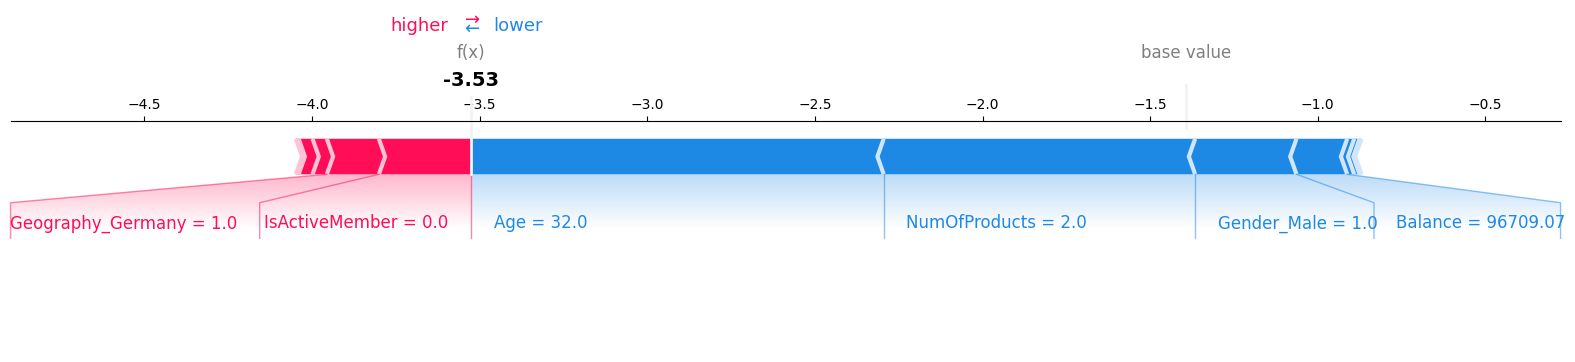

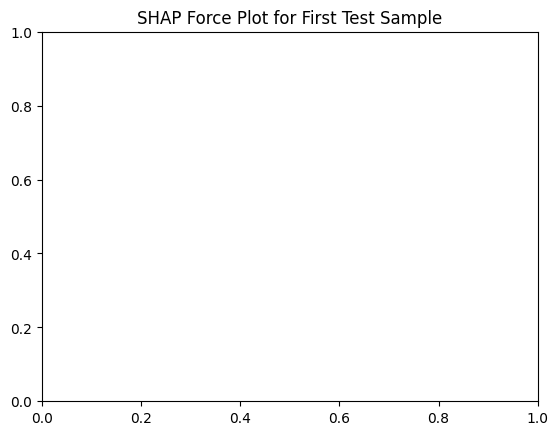

In [5]:
import shap
import matplotlib.pyplot as plt

# Use XGBoost as best model
best_model = models["XGBoost"]

#Create SHAP explainer
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values(using 200 samples for speed)
shap_values = explainer.shap_values(X_test_scaled[:200])

print("SHAP values calculated!")

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled[:200], feature_names=X.columns, show=False)
plt.title("SHAP Summary Plot for XGBoost")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0], feature_names=X.columns, matplotlib=True)
plt.title("SHAP Force Plot for First Test Sample")

plt.show()


# BEst model Save

In [8]:
import joblib
import os

# Create model folder in project ROOT (not inside notebooks)
model_dir = os.path.join(os.path.dirname(os.getcwd()), "model")
os.makedirs(model_dir, exist_ok=True)

# Save the model in the correct location
joblib.dump(models["XGBoost"], os.path.join(model_dir, "xgboost_model.pkl"))

print("✅ Model saved successfully in correct location!")
print("Path:", os.path.join(model_dir, "xgboost_model.pkl"))

✅ Model saved successfully in correct location!
Path: /Users/amritanshudash/Desktop/ChurnGuard/model/xgboost_model.pkl
